In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

                                              Name  \
0               3 BHK Flatin Sargasan, Gandhinagar   
1               3 BHK Flatin Pethapur, Gandhinagar   
2                 3 BHK Flatin Raysan, Gandhinagar   
3                 3 BHK Flatin Raysan, Gandhinagar   
4  3 BHK Flatin Urjanagar 1, Randesan, Gandhinagar   

                             Location  Price (INR in Lakhs)  Price_per_sqft  \
0               Sargasan, Gandhinagar                126.00          4320.0   
1               Pethapur, Gandhinagar                 51.99          2962.0   
2                 Raysan, Gandhinagar                 97.00          5083.0   
3                 Raysan, Gandhinagar                125.00          5669.0   
4  Urjanagar 1, Randesan, Gandhinagar                 79.00          4501.0   

   Area_sqft  \
0     2916.0   
1     1755.0   
2     1908.0   
3     2205.0   
4     1755.0   

                                                                                                       

In [ ]:
# 1. Load data
df = pd.read_csv('data\gandhinagar_property_apartments_cleaned.csv')

# Display first few rows
df.head()

In [84]:
df['luxury_score'].value_counts()

luxury_score
 0.0     930
 2.0      68
-1.0      24
 7.0      23
 5.0      22
 6.0      21
 3.0      21
 4.0      21
 8.0      18
 1.0      11
 9.0       8
 10.0      7
 12.0      6
 16.0      6
 14.0      4
 15.0      3
 11.0      3
 24.0      2
 17.0      2
 21.0      1
 26.0      1
 22.0      1
Name: count, dtype: int64

In [41]:
df['location_advantage_score'].value_counts()

location_advantage_score
0.0     959
1.0      50
2.0      46
3.0      44
4.0      24
5.0      23
10.0     21
6.0      14
7.0      11
8.0       7
16.0      2
15.0      1
9.0       1
Name: count, dtype: int64

In [85]:
import re

def extract_bhk(name):
    if pd.isna(name):
        return 'Unknown'
    match = re.search(r'(\d+)\s*(BHK|RK)', str(name), re.IGNORECASE)
    if match:
        num = match.group(1)
        typ = match.group(2).upper()
        if typ == 'RK':
            return f"{num}RK"
        else:
            return f"{num} {typ}"  # e.g., "3 BHK"
    return 'Unknown'

df['BHK'] = df['Name'].apply(extract_bhk)

In [61]:
df['BHK'].value_counts()

BHK
2 BHK      555
3 BHK      536
1 BHK       94
4 BHK       87
1RK         22
5 BHK        5
6 BHK        3
Unknown      2
Name: count, dtype: int64

In [62]:
# to show ful value of each col
pd.set_option('display.max_colwidth', None)

In [45]:
df['Bedrooms'].value_counts()

Bedrooms
2.0    556
3.0    536
1.0    117
4.0     87
5.0      5
6.0      3
Name: count, dtype: int64

In [46]:
df[df['Name'].str.contains('RK')][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','BHK','Property_URL','is_carpet_area','is_super_built_up_area','is_built_up_area']].head(10)

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Bedrooms,BHK,Property_URL,is_carpet_area,is_super_built_up_area,is_built_up_area
9,"Studio Apartments / 1 RK Flatsin Gift City, Gandhinagar",97.00,20082.0,483.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-483-sqft-spid-C89513918,True,False,False
214,"Studio Apartments / 1 RK Flatsin Chhatral, Gandhinagar",15.00,4285.0,350.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-chhatral-gandhinagar-350-sqft-spid-Z89633010,True,False,False
529,"Studio Apartments / 1 RK Flatsin Gift City, Gandhinagar",62.70,9500.0,660.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-gift-city-gandhinagar-660-sqft-spid-F89990080,False,True,False
613,"Studio Apartments / 1 RK Flatsin Gift City, Gandhinagar",59.85,9500.0,630.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-gift-city-gandhinagar-630-sqft-spid-L89998408,False,True,False
884,"Studio Apartments / 1 RK Flatsin Gift City, Gandhinagar",110.00,22774.0,483.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-483-sqft-spid-T90064230,True,False,False
978,"Studio Apartments / 1 RK Flatsin Kolavada, Gandhinagar",25.00,3125.0,800.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-swarna-amrut-heights-kolavada-gandhinagar-800-sqft-spid-S89193833,True,False,False
1017,"Studio Apartments / 1 RK Flatsin Randheja, Gandhinagar",22.00,4889.0,450.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-randheja-gandhinagar-450-sqft-spid-L88732332,True,False,False
1018,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar",11.50,2719.0,423.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-423-sqft-spid-V88724330,False,True,False
1083,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar",12.00,2182.0,550.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-550-sqft-spid-U88162294,True,False,False
1084,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar",14.00,2545.0,550.0,1.0,1RK,https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-550-sqft-spid-T88162072,True,False,False


In [9]:
df['Mapped_Area'].nunique()

34

In [11]:
df['Price (INR in Lakhs)'].describe()

count    1304.000000
mean       92.610966
std        63.018113
min         7.000000
25%        55.000000
50%        75.000000
75%       112.000000
max       500.000000
Name: Price (INR in Lakhs), dtype: float64

In [12]:
df['log_price'].describe()

count    1304.000000
mean        4.364569
std         0.587268
min         2.079442
25%         4.025352
50%         4.330733
75%         4.727388
max         6.216606
Name: log_price, dtype: float64

In [13]:
df['Price_per_sqft'].describe()

count     1304.000000
mean      6019.748305
std       3420.482389
min       1728.000000
25%       4117.250000
50%       4762.000000
75%       6717.000000
max      26984.000000
Name: Price_per_sqft, dtype: float64

In [14]:
df['pps'].describe()

count     1304.000000
mean      5919.765337
std       3345.630429
min       1728.000000
25%       4084.750000
50%       4730.500000
75%       6429.000000
max      26984.000000
Name: pps, dtype: float64

In [15]:
df['Area_sqft'].describe()

count    1304.000000
mean     1663.016125
std       922.295172
min       210.000000
25%      1094.250000
50%      1449.000000
75%      2071.858175
max      9000.000000
Name: Area_sqft, dtype: float64

In [86]:
df.loc[16,'is_carpet_area']=True
df.loc[46,'Area_sqft']=1170
df.loc[46,'is_carpet_area']=True
df.loc[60,'is_carpet_area']=True
df.loc[103,'is_super_built_up_area']=True
df.loc[154,'Area_sqft']=1122.56
df.loc[154,'is_carpet_area']=True
df.loc[189,'is_carpet_area']=True
df.loc[205,'is_super_built_up_area']=True
df.loc[210,'Area_sqft']=1071
df.loc[210,'is_carpet_area']=True
df.loc[241,'is_carpet_area']=True
df.loc[264,'is_carpet_area']=True
df.loc[400,'is_super_built_up_area']=True
df.loc[469,'is_carpet_area']=True
df.loc[519,'Area_sqft']=2025
df.loc[519,'is_super_built_up_area']=True
df.loc[536,'is_carpet_area']=True
df.loc[571,'is_carpet_area']=True
df.loc[574,'is_carpet_area']=True
df.loc[604,'is_carpet_area']=True
df.loc[615,'is_carpet_area']=True
df.loc[617,'Area_sqft']=1242
df.loc[617,'is_super_built_up_area']=True
df.loc[681,'is_carpet_area']=True
df.loc[703,'is_super_built_up_area']=True
df.loc[774,'is_super_built_up_area']=True
df.loc[792,'is_super_built_up_area']=True
df.loc[794,'is_built_up_area']=True
df.loc[795,'is_built_up_area']=True
df.loc[803,'is_carpet_area']=True
df.loc[821,'is_carpet_area']=True
df.loc[829,'is_carpet_area']=True
df.loc[890,'is_built_up_area']=True
df.loc[949,'Area_sqft']=765
df.loc[949,'is_built_up_area']=True
df.loc[954,'is_super_built_up_area']=True
df.loc[966,'is_built_up_area']=True
df.loc[988,'is_carpet_area']=True
df.loc[1021,'is_carpet_area']=True
df.loc[1035,'Area_sqft']=2043
df.loc[1035,'is_super_built_up_area']=True
df.loc[1166,'is_carpet_area']=True
df.loc[1196,'is_carpet_area']=True
df.loc[1226,'is_carpet_area']=True
df.loc[1297,'is_carpet_area']=True
df.loc[1300,'is_super_built_up_area']=True

In [22]:
df[(df['is_built_up_area']==False) & (df['is_carpet_area']==False) & (df['is_super_built_up_area']==False)]

,Name,Location,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Description,Property_URL,bedrooms,bathrooms,balconies,...,is_built_up_area,is_carpet_area,is_super_built_up_area,property_type,luxury_score,location_advantage_score,log_price,Bedrooms,pps,BHK


In [87]:
# Create Area_type column
df['Area_type'] = np.select(
    [
        df['is_super_built_up_area'] == 1,
        df['is_built_up_area'] == 1,
        df['is_carpet_area'] == 1
    ],
    [
        'Super Built-up',
        'Built-up',
        'Carpet'
    ],
    default='Unknown'
)

# Drop old columns
df.drop(
    columns=[
        'is_super_built_up_area',
        'is_built_up_area',
        'is_carpet_area'
    ],
    inplace=True
)

df['Status'] = df['is_ready_to_move'].map({
    1: 'Ready_to_Move',
    0: 'Under_Construction'
})

df.drop(columns=['is_ready_to_move'], inplace=True)


In [88]:
df['Area_type'] = df['Area_type'].astype('category')
df['Status'] = df['Status'].astype('category')

In [89]:
print(df['Area_type'].value_counts())
print(df['Status'].value_counts())

Area_type
Super Built-up    649
Carpet            527
Built-up          128
Name: count, dtype: int64
Status
Ready_to_Move         1061
Under_Construction     243
Name: count, dtype: int64


In [90]:
# df['Bedrooms'].describe()
# df['bathrooms'].describe()

df['property_age_bucket'].value_counts()

property_age_bucket
New            620
Unknown        340
1-5 years      165
5-10 years     119
10-20 years     60
Name: count, dtype: int64

In [28]:
df['property_type'].value_counts()

property_type
apartment        1257
builder floor      32
penthouse          15
Name: count, dtype: int64

In [91]:
df['luxury_score'].value_counts()

luxury_score
 0.0     930
 2.0      68
-1.0      24
 7.0      23
 5.0      22
 6.0      21
 3.0      21
 4.0      21
 8.0      18
 1.0      11
 9.0       8
 10.0      7
 12.0      6
 16.0      6
 14.0      4
 15.0      3
 11.0      3
 24.0      2
 17.0      2
 21.0      1
 26.0      1
 22.0      1
Name: count, dtype: int64

In [80]:
def categorize(score):
    if score == 0:
        return "Unknown"
    elif score <= 3:
        return "Basic"
    elif score <= 10:
        return "Premium"
    else:
        return "Luxury"

df['luxury_category']=df['luxury_score'].apply(categorize).value_counts()

In [96]:
df[(df['Description'].isnull()) & (df['luxury_score'].isnull()) & (df['location_advantage_score'].isnull())][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','BHK','Property_URL','luxury_score','location_advantage_score']].shape

(101, 9)

In [97]:
# 1. Identify rows with null Description
null_desc_mask = df['Description'].isna()

# 2. For these rows, set the scores to 0 (or any default value you prefer)
# Setting to 0 aligns with "luxury_score == 0" mapping to "Unknown"
df.loc[null_desc_mask, 'luxury_score'] = 0
df.loc[null_desc_mask, 'location_advantage_score'] = 0

In [100]:
df[(df['Description'].isnull()) ][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','BHK','Property_URL','luxury_score','location_advantage_score']].shape

(101, 9)

In [106]:
def categorize(score):
    if score == 0:
        return "Unknown"
    elif score <= 3:
        return "Basic"
    elif score <= 8:
        return "Premium"
    else:
        return "Luxury"

df['luxury_category']=df['luxury_score'].apply(categorize)

In [107]:
df['location_advantage_score'].value_counts()

location_advantage_score
0.0     1060
1.0       50
2.0       46
3.0       44
4.0       24
5.0       23
10.0      21
6.0       14
7.0       11
8.0        7
16.0       2
15.0       1
9.0        1
Name: count, dtype: int64

In [112]:
def categorize_location_advantage(score):
    if score == 0:
        return "Unknown"
    elif score <= 3:
        return "Basic"
    elif score <= 7:
        return "Good"
    else:
        return "Excellent"
    
df['location_advantage_category'] = df['location_advantage_score'].apply(categorize_location_advantage)

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Name                         1304 non-null   str     
 1   Location                     1304 non-null   str     
 2   Price (INR in Lakhs)         1304 non-null   float64 
 3   Price_per_sqft               1304 non-null   float64 
 4   Area_sqft                    1304 non-null   float64 
 5   Description                  1203 non-null   str     
 6   Property_URL                 1304 non-null   str     
 7   bedrooms                     1302 non-null   float64 
 8   bathrooms                    1304 non-null   float64 
 9   balconies                    1304 non-null   float64 
 10  current_floor                1304 non-null   float64 
 11  total_floors                 1304 non-null   float64 
 12  furnishing_status            1304 non-null   str     
 13  Mapped_Area   

In [114]:
df['BHK']=df['BHK'].astype('category')
df['luxury_category']=df['luxury_category'].astype('category')
df['location_advantage_category']=df['location_advantage_category'].astype('category')

In [72]:
df['location_advantage_score'].value_counts()

location_advantage_score
0.0     959
1.0      50
2.0      46
3.0      44
4.0      24
5.0      23
10.0     21
6.0      14
7.0      11
8.0       7
16.0      2
15.0      1
9.0       1
Name: count, dtype: int64

In [81]:
df['luxury_category'].value_counts()

Series([], Name: count, dtype: int64)

In [118]:
df.columns

Index(['Location', 'Price (INR in Lakhs)', 'Area_sqft', 'bathrooms',
       'balconies', 'current_floor', 'total_floors', 'furnishing_status',
       'Mapped_Area', 'facing', 'property_age_bucket', 'property_type',
       'luxury_score', 'location_advantage_score', 'Bedrooms', 'BHK',
       'Area_type', 'Status', 'luxury_category',
       'location_advantage_category'],
      dtype='str')

In [117]:
df.drop(columns=['log_price','pps','Name','Price_per_sqft','bedrooms','Description','Property_URL'], inplace=True)

In [119]:
df['floor_ratio'] = df['current_floor'] / df['total_floors']

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

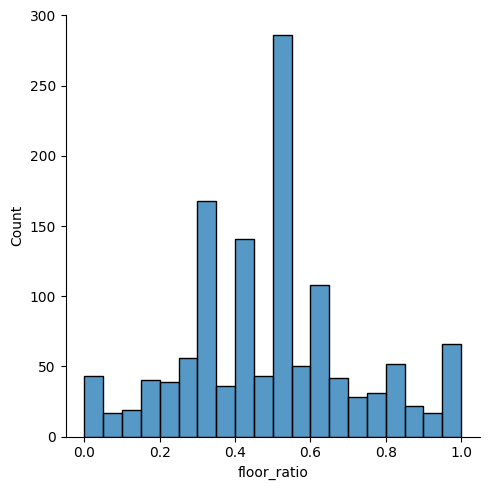

In [133]:
sns.displot(x=df['floor_ratio'])
plt.show()

In [137]:
q1=df['floor_ratio'].quantile(0.25)
q2=df['floor_ratio'].quantile(0.5)
q3=df['floor_ratio'].quantile(0.75)
print(q1,q2,q3)

0.34 0.5 0.625


In [140]:
def floor_category(ratio):
    if ratio == 1:
        return "Top Floor"
    elif ratio <= 0.34:
        return "Lower Floor"
    elif ratio <= 0.625:
        return "Mid Floor"
    else:
        return "Higher Floor"
    
df['floor_category']=df['floor_ratio'].apply(floor_category)

In [142]:
df.drop(columns=['luxury_score','location_advantage_score'], inplace=True)

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Location                     1304 non-null   str     
 1   Price (INR in Lakhs)         1304 non-null   float64 
 2   Area_sqft                    1304 non-null   float64 
 3   bathrooms                    1304 non-null   float64 
 4   balconies                    1304 non-null   float64 
 5   current_floor                1304 non-null   float64 
 6   total_floors                 1304 non-null   float64 
 7   furnishing_status            1304 non-null   str     
 8   Mapped_Area                  1304 non-null   str     
 9   facing                       1304 non-null   str     
 10  property_age_bucket          1304 non-null   str     
 11  property_type                1304 non-null   str     
 12  Bedrooms                     1304 non-null   float64 
 13  BHK           

In [144]:
df.to_csv('data//test.csv', index=False)

In [55]:
df.drop(columns=['bedrooms'],inplace=True)

In [ ]:
df.drop(columns=(['Name','log_price','Price_per_sqft','pps','luxury_score', 'location_advantage_score', 'luxury_category',
       'location_advantage_category']), inplace=True)

In [52]:
df['Description'].value_counts()

Description
                                                                                                                                                                                                                                                                                                                                                                                                                    101
Property is in the prime location. Please contatct for further information.                                                                                                                                                                                                                                                                                                                                           7
Sobha elysia redefines international living with its sleek modern facade and stands tall as a testament to architectural brilliance, offering a luxurious experience replete

In [57]:

# 1. Define the manual mapping (old_name → new_name)
rename_dict = {
    'Location': 'location',
    'Price (INR in Lakhs)': 'price_inr_in_lakhs',
    'Area_sqft': 'area_sqft',
    'Description': 'description',
    'Property_URL': 'property_url',
    'bathrooms': 'bathrooms',
    'balconies': 'balconies',
    'current_floor': 'current_floor',
    'total_floors': 'total_floors',
    'furnishing_status': 'furnishing_status',
    'Mapped_Area': 'mapped_area',
    'facing': 'facing',
    'property_age_bucket': 'property_age',         
    'property_type': 'property_type',
    'Bedrooms': 'bedrooms',                    
    'Area_type': 'area_type',
    'Status': 'property_status'                     
}

In [59]:
df.rename(columns=rename_dict, inplace=True)

In [60]:
df.to_csv('data\\gandhinagar_property_apartments_recommender_ready.csv', index=False)

In [61]:
df=pd.read_csv('data\gandhinagar_property_apartments_recommender_ready.csv')

In [ ]:
df.head()

,location,price_inr_in_lakhs,area_sqft,description,property_url,bathrooms,balconies,current_floor,total_floors,furnishing_status,mapped_area,facing,property_age,property_type,bedrooms,area_type,property_status
0,"Sargasan, Gandhinagar",126.00,2916.0,Experience a new style of living with Altezza ...,https://www.99acres.com/3-bhk-bedroom-apartmen...,3.0,1.0,4.0,8.0,Unknown,Sargasan,Unknown,New,apartment,3.0,Super Built-up,Ready_to_Move
1,"Pethapur, Gandhinagar",51.99,1755.0,Experience a new style of living with Satyamev...,https://www.99acres.com/3-bhk-bedroom-apartmen...,3.0,2.0,3.0,7.0,Unknown,Pethapur,Unknown,New,apartment,3.0,Super Built-up,Under_Construction
2,"Raysan, Gandhinagar",97.00,1908.0,This is your chance to a 3 bhk apartment / fla...,https://www.99acres.com/3-bhk-bedroom-apartmen...,3.0,2.0,4.0,8.0,Unknown,Raysan,Unknown,New,apartment,3.0,Super Built-up,Ready_to_Move
3,"Raysan, Gandhinagar",125.00,2205.0,We are the proud owners of this 3 bhk apartmen...,https://www.99acres.com/3-bhk-bedroom-apartmen...,2.0,2.0,9.0,13.0,Unknown,Raysan,Unknown,New,apartment,3.0,Carpet,Ready_to_Move
4,"Urjanagar 1, Randesan, Gandhinagar",79.00,1755.0,Situated on the top floor (8th) of a mid-Rise ...,https://www.99acres.com/3-bhk-bedroom-apartmen...,3.0,1.0,8.0,13.0,unfurnished,Randesan,Unknown,5-10 years,apartment,3.0,Carpet,Ready_to_Move
